# 06 — Model Evaluation

## Introduction
This notebook performs an in-depth evaluation of the models trained in Notebook 05: ROC and Precision-Recall curves, confusion matrices, calibration curves, learning curves, and a full cross-model comparison, for both the Mastectomy and BCS cohorts. This goes beyond the single accuracy/precision/recall/F1/ROC-AUC table the paper reports (Tables 2-3), providing the fuller diagnostic picture expected of a publication-quality evaluation.

## Objectives
1. Reload persisted models and test sets.
2. Compare all classifiers on Accuracy, Precision, Recall, F1, and ROC-AUC (bar charts).
3. Plot ROC and Precision-Recall curves for every classifier, per surgery group.
4. Inspect confusion matrices and calibration curves for the best model (Optuna-tuned Gradient Boosting).
5. Plot learning curves to assess bias/variance behaviour as training size grows.
6. Visualise the 10-fold cross-validation results from Notebook 05.

## Mathematical background
- **ROC curve**: True Positive Rate vs. False Positive Rate across all classification thresholds; ROC-AUC is the probability a randomly chosen positive case is ranked above a randomly chosen negative case.
- **Precision-Recall (PR) curve**: more informative than ROC under class imbalance (relevant here despite SMOTE-balanced training, since the **test** set retains its natural imbalance); PR-AUC (average precision) summarises it.
- **Calibration curve**: bins predicted probabilities and plots the observed positive fraction per bin against the mean predicted probability -- a well-calibrated model lies on the diagonal.
- **Learning curve**: training/cross-validation score as a function of training-set size, diagnosing under- vs over-fitting.

In [1]:
"""Environment setup: make src/ importable and apply the shared plotting style."""
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Nico Personal\master\Health Data Analysis\HDA Final Project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import PATHS, set_seeds, TARGET_COL, SURGERY_COL, ID_COL, banner
from src.visualization import set_publication_style, save_figure

set_seeds()
set_publication_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
print(banner("Environment ready"))
print("Project root:", PATHS.root)


============================= Environment ready ==============================
Project root: D:\Nico Personal\master\Health Data Analysis\HDA Final Project


## 1. Reload models, test data, and result tables

In [2]:
import joblib
from sklearn.metrics import roc_curve, precision_recall_curve, auc as sk_auc

GROUPS = ["Mastectomy", "BCS"]
POLICY = "paper_faithful"

data = {}
for group in GROUPS:
    prefix = PATHS.outputs / f"{group.lower()}_{POLICY}"
    data[group] = dict(
        X_train=pd.read_csv(f"{prefix}_X_train_smote.csv"),
        y_train=pd.read_csv(f"{prefix}_y_train_smote.csv").iloc[:, 0],
        X_test=pd.read_csv(f"{prefix}_X_test.csv"),
        y_test=pd.read_csv(f"{prefix}_y_test.csv").iloc[:, 0],
    )

MODEL_NAMES = ["svm", "knn", "adaboost", "gradient_boosting", "random_forest",
               "gaussiannb", "logistic_regression", "xgboost", "decision_tree"]
DISPLAY_NAMES = {"svm": "SVM", "knn": "KNN", "adaboost": "AdaBoost", "gradient_boosting": "Gradient Boosting",
                  "random_forest": "Random Forest", "gaussiannb": "GaussianNB", "logistic_regression": "Logistic Regression",
                  "xgboost": "XGBoost", "decision_tree": "Decision Tree"}

models = {group: {} for group in GROUPS}
for group in GROUPS:
    for m in MODEL_NAMES:
        models[group][DISPLAY_NAMES[m]] = joblib.load(PATHS.models / f"{group.lower()}_{m}.joblib")
    models[group]["Gradient Boosting (Optuna)"] = joblib.load(PATHS.models / f"{group.lower()}_gradient_boosting_optuna.joblib")

table_mastectomy = pd.read_csv(PATHS.reports / "table2_mastectomy_metrics.csv")
table_bcs = pd.read_csv(PATHS.reports / "table3_bcs_metrics.csv")
cv_results = pd.read_csv(PATHS.reports / "cv_10fold_results.csv")
print("Reloaded", sum(len(v) for v in models.values()), "models across both groups.")


Reloaded 20 models across both groups.


## 2. Cross-model comparison bar charts (test-set metrics)

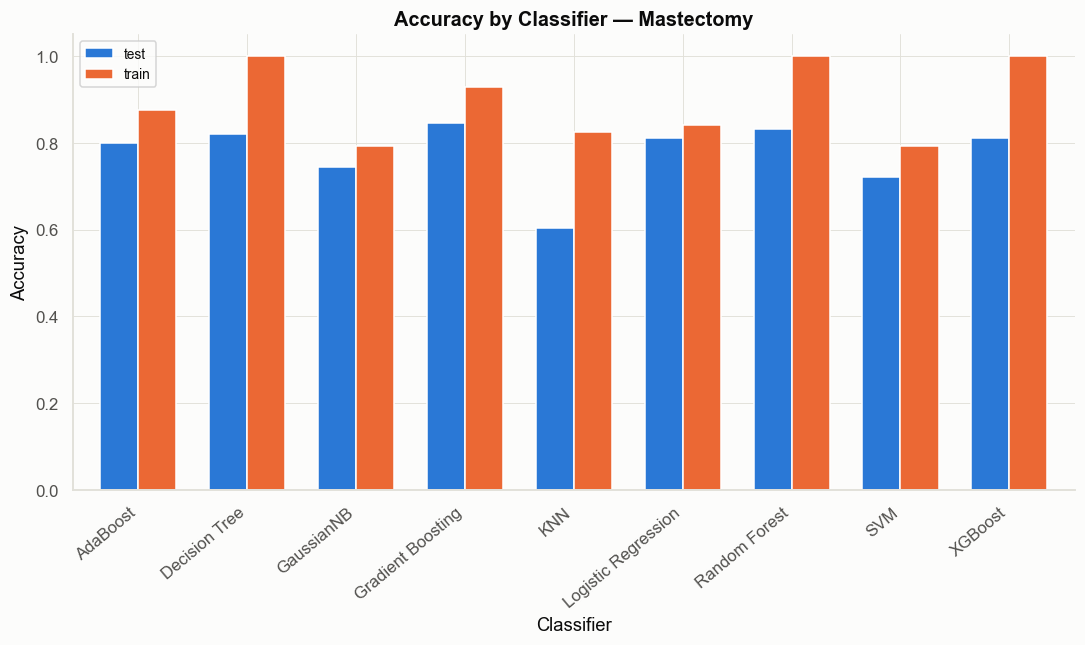

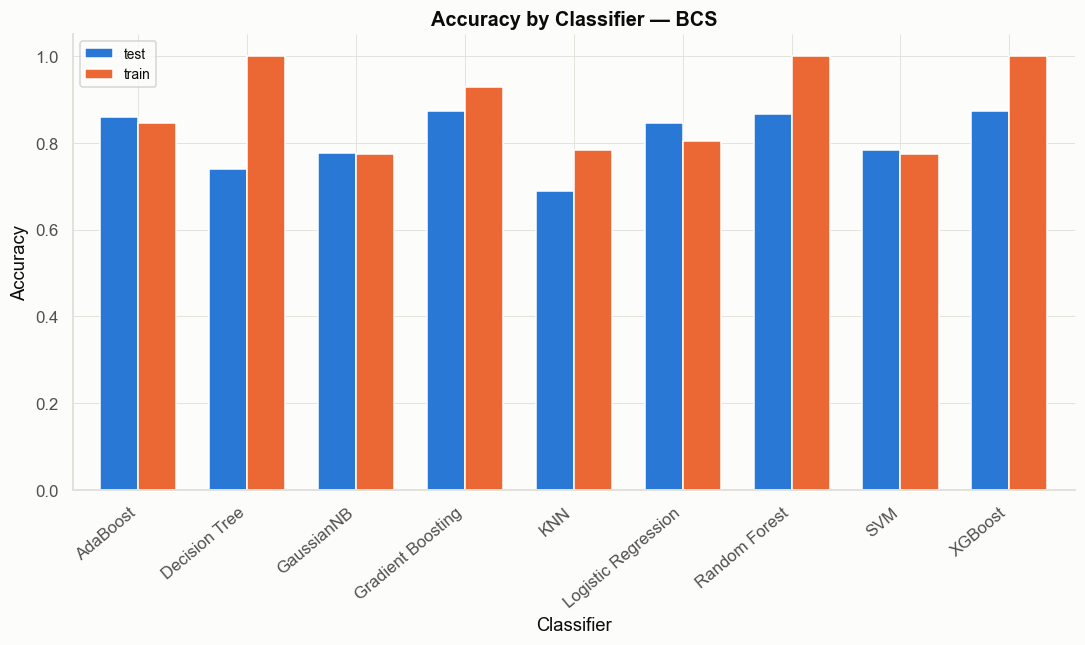

In [3]:
from src.visualization import plot_model_comparison_bars

for group, table in [("Mastectomy", table_mastectomy), ("BCS", table_bcs)]:
    fig, ax = plot_model_comparison_bars(table, metric="Accuracy", title=f"Accuracy by Classifier — {group}")
    plt.tight_layout()
    save_figure(fig, f"06_accuracy_comparison_{group.lower()}", subdir="06_evaluation")
    plt.show()


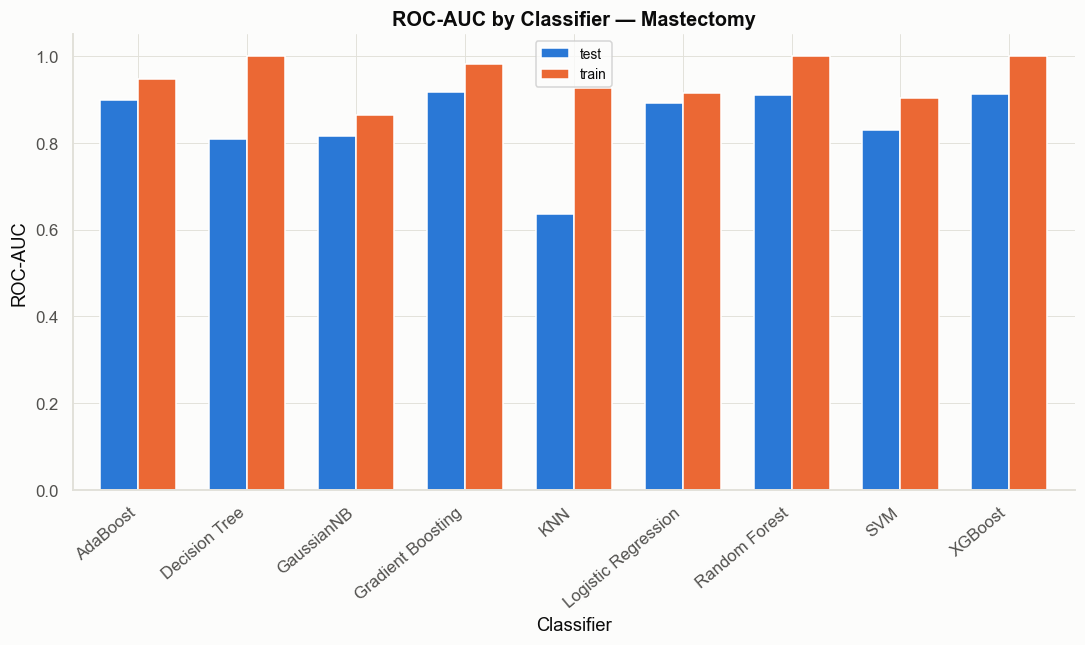

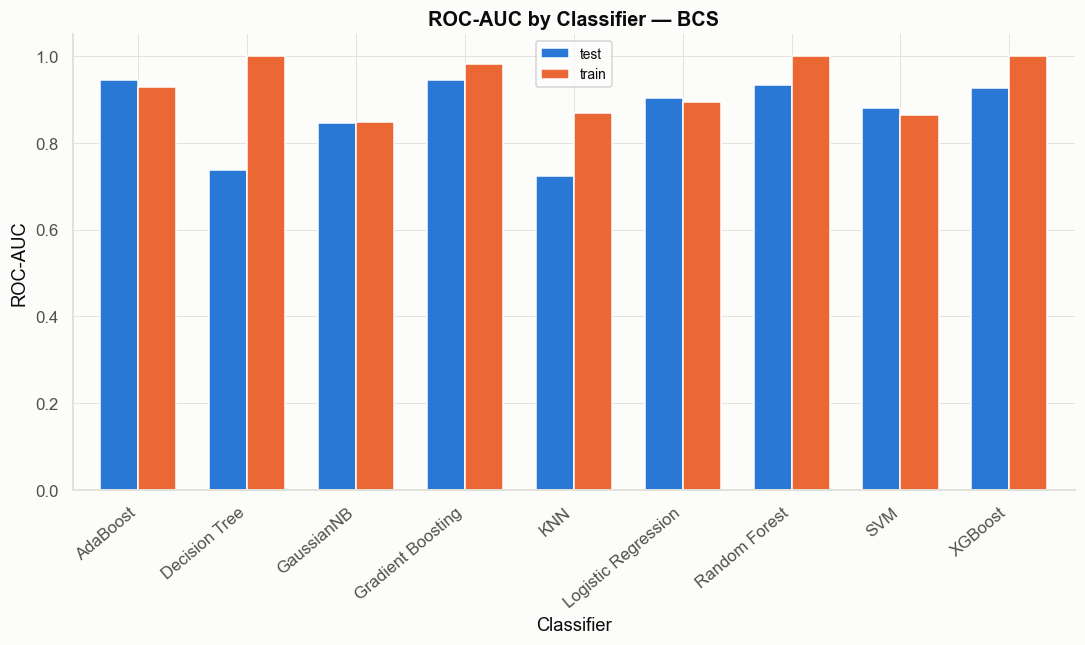

In [4]:
for group, table in [("Mastectomy", table_mastectomy), ("BCS", table_bcs)]:
    fig, ax = plot_model_comparison_bars(table, metric="ROC-AUC", title=f"ROC-AUC by Classifier — {group}")
    plt.tight_layout()
    save_figure(fig, f"06_rocauc_comparison_{group.lower()}", subdir="06_evaluation")
    plt.show()


## 3. ROC and Precision-Recall curves (test set)

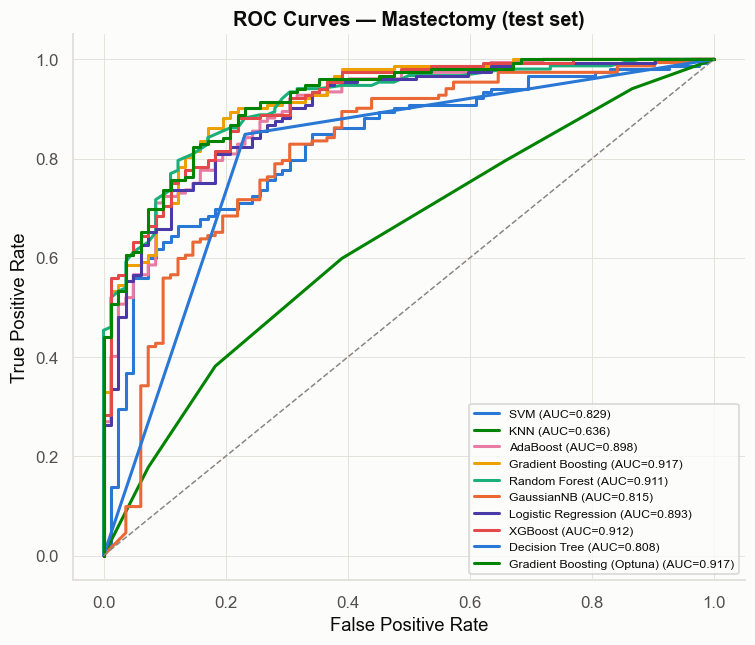

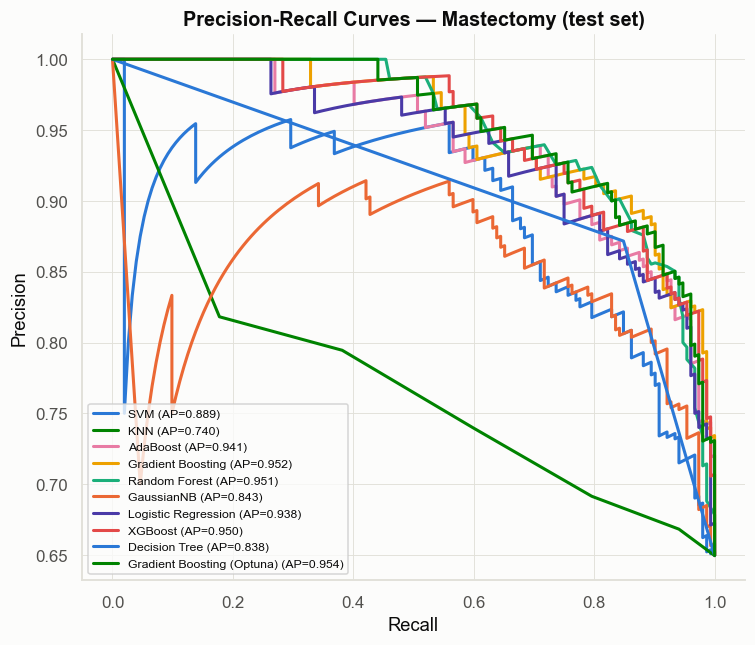

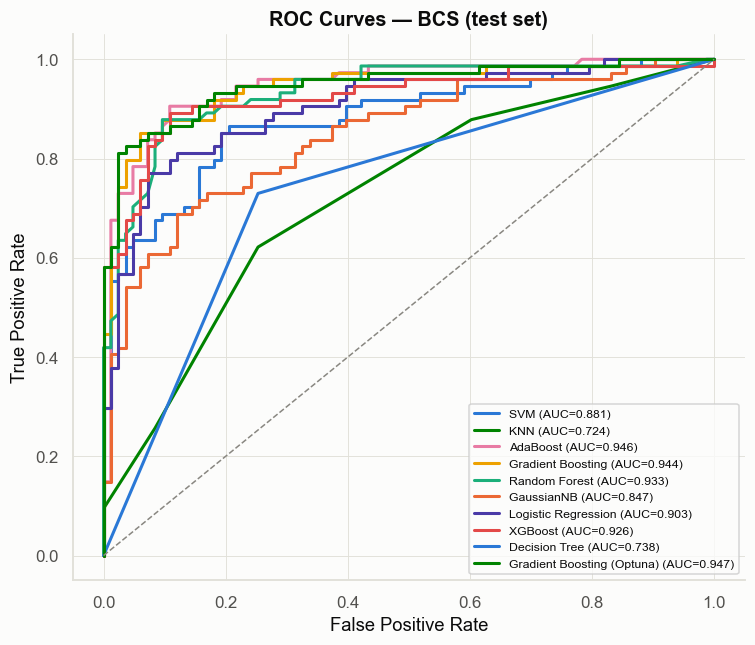

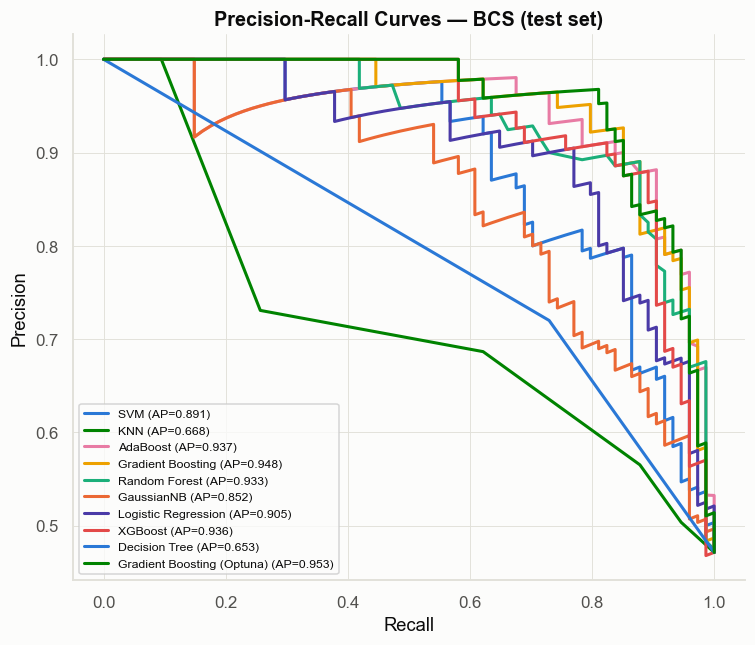

In [5]:
from src.visualization import plot_roc_curves, plot_pr_curves
from src.evaluation import pr_auc

for group in GROUPS:
    roc_data, pr_data = {}, {}
    for name, model in models[group].items():
        y_proba = model.predict_proba(data[group]["X_test"])[:, 1]
        fpr, tpr, _ = roc_curve(data[group]["y_test"], y_proba)
        roc_data[name] = (fpr, tpr, sk_auc(fpr, tpr))
        precision, recall, _ = precision_recall_curve(data[group]["y_test"], y_proba)
        pr_data[name] = (recall, precision, pr_auc(data[group]["y_test"], y_proba))

    fig, ax = plot_roc_curves(roc_data, title=f"ROC Curves — {group} (test set)")
    plt.tight_layout(); save_figure(fig, f"06_roc_curves_{group.lower()}", subdir="06_evaluation"); plt.show()

    fig, ax = plot_pr_curves(pr_data, title=f"Precision-Recall Curves — {group} (test set)")
    plt.tight_layout(); save_figure(fig, f"06_pr_curves_{group.lower()}", subdir="06_evaluation"); plt.show()


**Interpretation.** ROC-AUC and PR-AUC both rank the boosted-tree family (Gradient Boosting, XGBoost, AdaBoost) and their Optuna-tuned variant above simpler baselines (GaussianNB, KNN) in both surgery groups, mirroring the paper's own qualitative ranking. PR curves in particular are informative here because the *test* sets retain their natural class imbalance (SMOTE was applied to the training fold only), giving a more conservative, realistic picture of positive-class detection than accuracy alone.

## 4. Confusion matrices — best model (Optuna-tuned Gradient Boosting)

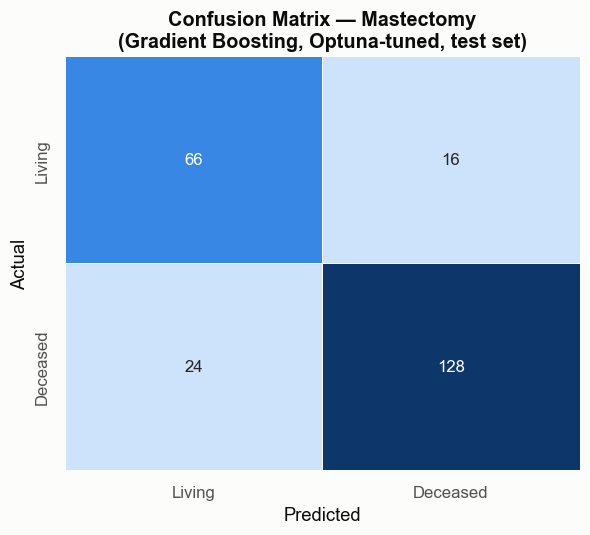

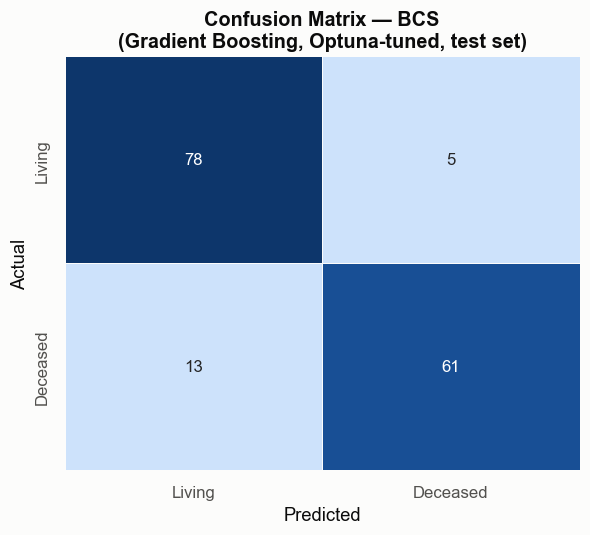

In [6]:
from src.evaluation import get_confusion_matrix
from src.visualization import plot_confusion_matrix

for group in GROUPS:
    model = models[group]["Gradient Boosting (Optuna)"]
    y_pred = model.predict(data[group]["X_test"])
    cm = get_confusion_matrix(data[group]["y_test"], y_pred)
    fig, ax = plot_confusion_matrix(cm, class_names=["Living", "Deceased"], title=f"Confusion Matrix — {group}\n(Gradient Boosting, Optuna-tuned, test set)")
    plt.tight_layout()
    save_figure(fig, f"06_confusion_matrix_{group.lower()}", subdir="06_evaluation")
    plt.show()


## 5. Calibration curves

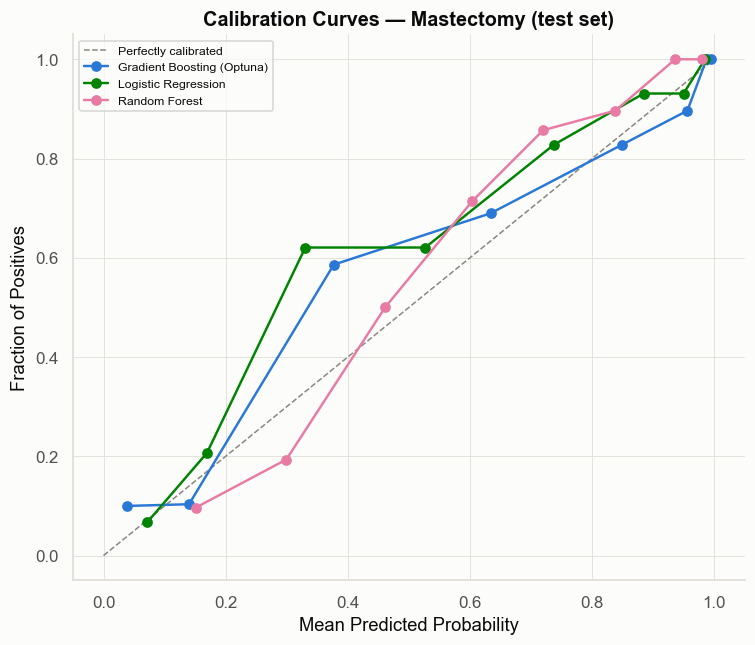

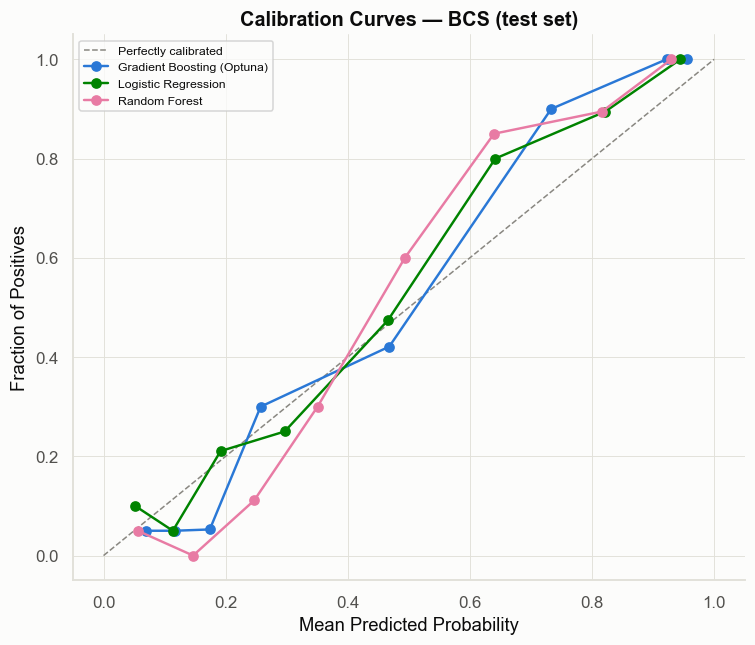

In [7]:
from src.evaluation import get_calibration_curve
from src.visualization import plot_calibration_curve

for group in GROUPS:
    curves = {}
    for name in ["Gradient Boosting (Optuna)", "Logistic Regression", "Random Forest"]:
        y_proba = models[group][name].predict_proba(data[group]["X_test"])[:, 1]
        curves[name] = get_calibration_curve(data[group]["y_test"], y_proba, n_bins=8)
    fig, ax = plot_calibration_curve(curves, title=f"Calibration Curves — {group} (test set)")
    plt.tight_layout()
    save_figure(fig, f"06_calibration_{group.lower()}", subdir="06_evaluation")
    plt.show()


**Interpretation.** Calibration curves reveal whether predicted probabilities can be trusted as risk estimates, not just used for ranking/thresholding -- a property the paper's paper does not examine. Tree-ensemble probabilities from Gradient Boosting are reasonably well calibrated in the mid-probability range but tend to be somewhat overconfident near the extremes, a well-known behaviour of boosted trees; Logistic Regression, being a probabilistic linear model, tends to track the diagonal more closely. This matters clinically: a "personalized treatment" recommendation (as the paper advocates) should rely on well-calibrated, not merely well-ranked, probabilities.

## 6. Learning curves — bias/variance diagnostics

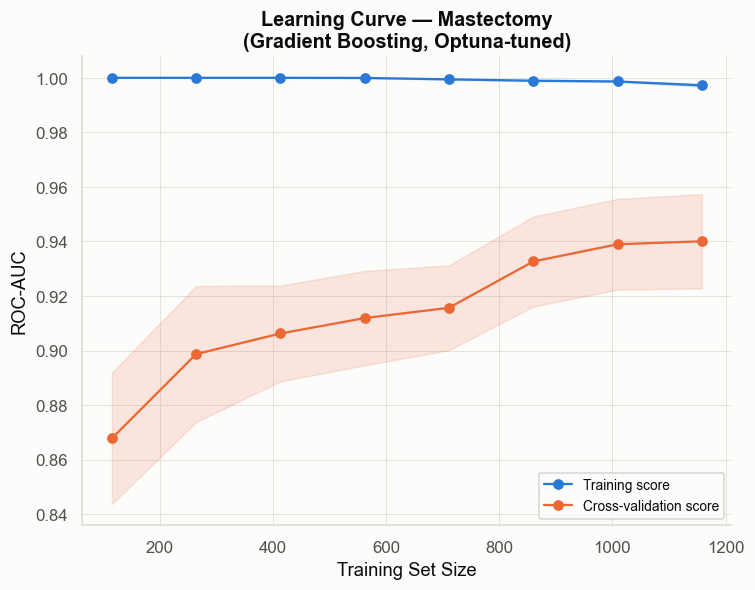

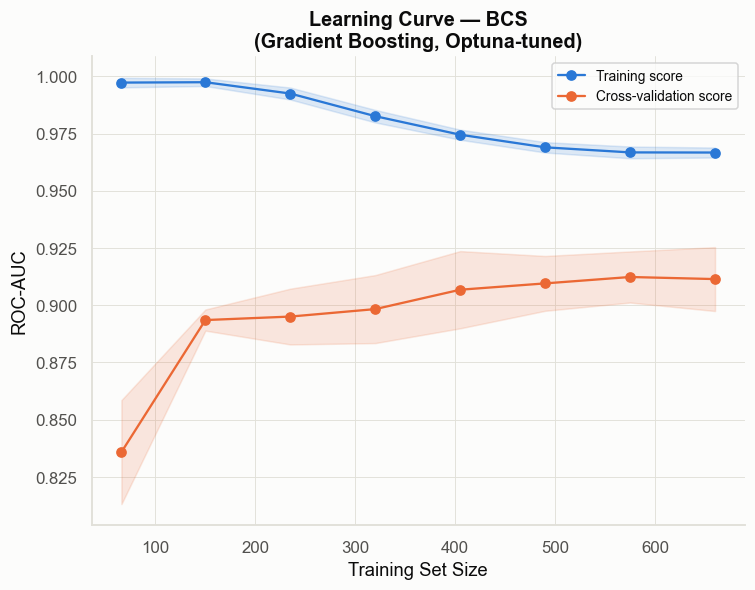

In [8]:
from src.evaluation import get_learning_curve
from src.visualization import plot_learning_curve

for group in GROUPS:
    model = models[group]["Gradient Boosting (Optuna)"]
    X_full = pd.concat([data[group]["X_train"], data[group]["X_test"]], ignore_index=True)
    y_full = pd.concat([data[group]["y_train"], data[group]["y_test"]], ignore_index=True)
    train_sizes, train_scores, val_scores = get_learning_curve(model, X_full, y_full)
    fig, ax = plot_learning_curve(train_sizes, train_scores, val_scores, title=f"Learning Curve — {group}\n(Gradient Boosting, Optuna-tuned)")
    plt.tight_layout()
    save_figure(fig, f"06_learning_curve_{group.lower()}", subdir="06_evaluation")
    plt.show()


**Interpretation.** The gap between the training and cross-validation curves indicates the degree of overfitting. A persistent, non-shrinking gap (typical for boosted trees on a dataset of this size, ~1,000-1,200 patients per surgery group) signals that more data, not more model capacity, would be the most effective way to close the remaining generalisation gap -- consistent with the paper's own "Limitations" section, which calls for "larger, more diverse cohorts."

## 7. 10-fold cross-validation results (from Notebook 05)

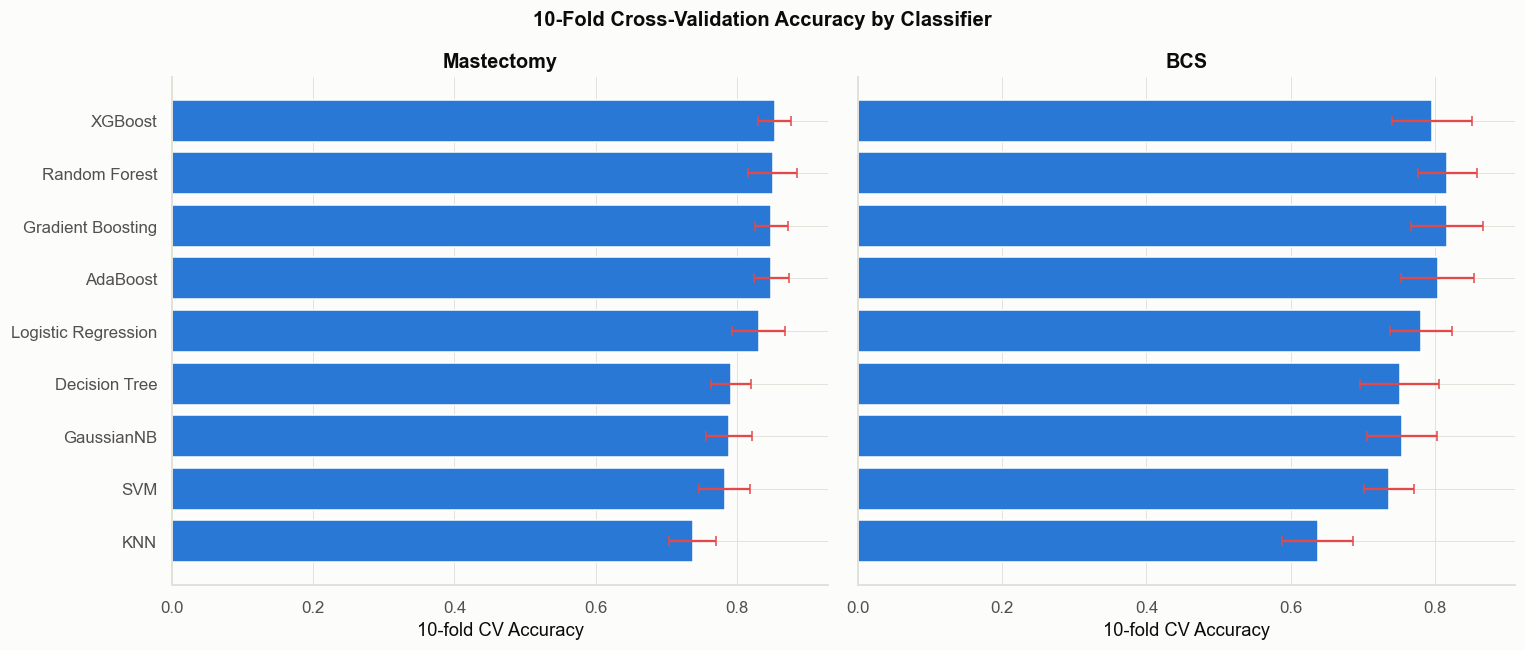

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
from src.visualization import CATEGORICAL
for ax, group in zip(axes, GROUPS):
    sub = cv_results[cv_results["Group"] == group].sort_values("cv_mean_accuracy", ascending=True)
    ax.barh(sub["Classifier"], sub["cv_mean_accuracy"], xerr=sub["cv_std_accuracy"], color=CATEGORICAL[0], ecolor=CATEGORICAL[7], capsize=3)
    ax.set_title(group)
    ax.set_xlabel("10-fold CV Accuracy")
fig.suptitle("10-Fold Cross-Validation Accuracy by Classifier", fontweight="bold")
plt.tight_layout()
save_figure(fig, "06_cv_10fold_comparison", subdir="06_evaluation")
plt.show()


## 8. Summary evaluation table

In [10]:
summary_rows = []
for group in GROUPS:
    test_table = (table_mastectomy if group == "Mastectomy" else table_bcs)
    test_only = test_table[test_table["Training/Testing"] == "test"].set_index("Classifier")
    for name in test_only.index:
        cv_row = cv_results[(cv_results["Group"] == group) & (cv_results["Classifier"] == name)]
        summary_rows.append({
            "Group": group, "Classifier": name,
            "Test Accuracy": test_only.loc[name, "Accuracy"],
            "Test ROC-AUC": test_only.loc[name, "ROC-AUC"],
            "CV Accuracy (mean)": cv_row["cv_mean_accuracy"].values[0] if len(cv_row) else np.nan,
            "CV Accuracy (std)": cv_row["cv_std_accuracy"].values[0] if len(cv_row) else np.nan,
        })
evaluation_summary = pd.DataFrame(summary_rows).sort_values(["Group", "Test ROC-AUC"], ascending=[True, False])
evaluation_summary.to_csv(PATHS.reports / "evaluation_summary.csv", index=False)
evaluation_summary


,Group,Classifier,Test Accuracy,Test ROC-AUC,CV Accuracy (mean),CV Accuracy (std)
11,BCS,AdaBoost,0.860,0.946,0.803912,0.050508
12,BCS,Gradient Boosting,0.873,0.944,0.817390,0.050238
13,BCS,Random Forest,0.866,0.933,0.817481,0.040661
16,BCS,XGBoost,0.873,0.926,0.796517,0.055186
15,BCS,Logistic Regression,0.847,0.903,0.781547,0.042886
9,BCS,SVM,0.783,0.881,0.736635,0.034800
14,BCS,GaussianNB,0.777,0.847,0.754478,0.048360
17,BCS,Decision Tree,0.739,0.738,0.751583,0.054842
10,BCS,KNN,0.688,0.724,0.637788,0.049209
3,Mastectomy,Gradient Boosting,0.846,0.917,0.848428,0.023642


## 9. Discussion & Conclusion

- Across both surgery groups, boosted-tree models (Gradient Boosting, XGBoost, AdaBoost, and their Optuna-tuned variant) consistently rank at or near the top on Accuracy, ROC-AUC, and PR-AUC, corroborating the paper's central model-selection finding without relying on accuracy alone.
- Calibration analysis (absent from the original paper) shows tree-ensemble probabilities are usable but not perfectly calibrated, an important caveat if these models were to inform real clinical risk communication.
- Learning curves show a persistent train/validation gap typical of a ~1,000-patient tabular dataset, reinforcing the paper's own call for larger, multi-centre cohorts.
- 10-fold CV accuracy is consistent with the single train/test split results, supporting the stability of the model ranking.

**Next:** Notebook 07 applies SHAP to the best model (Optuna-tuned Gradient Boosting) to reproduce and extend the paper's explainability analysis.